<a href="https://colab.research.google.com/github/melvindeepesh-boop/Deep-Learning-Lab/blob/main/character_recognition_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [8]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


In [6]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


In [10]:
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

In [11]:

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.9182 - loss: 0.2700 - val_accuracy: 0.9815 - val_loss: 0.0665
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9755 - loss: 0.0822 - val_accuracy: 0.9870 - val_loss: 0.0502
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.9830 - loss: 0.0569 - val_accuracy: 0.9883 - val_loss: 0.0410
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9858 - loss: 0.0462 - val_accuracy: 0.9910 - val_loss: 0.0342
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 89ms/step - accuracy: 0.9880 - loss: 0.0391 - val_accuracy: 0.9902 - val_loss: 0.0369


In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print("\nTest Accuracy:", round(test_acc,4))
predictions = model.predict(X_test[:5])





Test Accuracy: 0.9918
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [17]:
print("Predicted Labels:", np.argmax(predictions, axis=1))
print("True Labels     :", y_test[:5])

Predicted Labels: [7 2 1 0 4]
True Labels     : [7 2 1 0 4]


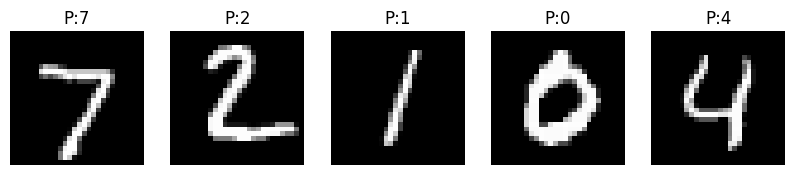

In [18]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title(f"P:{np.argmax(predictions[i])}")
    plt.axis("off")

plt.show()